In [ ]:
import kagglehub

path = kagglehub.dataset_download(
    "gunavenkatdoddi/eye-diseases-classification"
)

print("Path to dataset files:", path)


100%|██████████| 736M/736M [00:34<00:00, 22.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/gunavenkatdoddi/eye-diseases-classification/versions/1


In [ ]:
DATASET_PATH = "/root/.cache/kagglehub/datasets/gunavenkatdoddi/eye-diseases-classification/versions/1/dataset"

In [ ]:
!ls "$DATASET_PATH"

cataract  diabetic_retinopathy	glaucoma  normal


In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split


In [ ]:
DATASET_PATH = "/root/.cache/kagglehub/datasets/gunavenkatdoddi/eye-diseases-classification/versions/1/dataset"
IMG_SIZE = 224
BATCH_SIZE = 8
NUM_CLASSES = 4

In [ ]:
def apply_clahe(img):
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)

    merged = cv2.merge((cl, a, b))
    enhanced = cv2.cvtColor(merged, cv2.COLOR_LAB2RGB)
    return enhanced

In [ ]:
def preprocess_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = apply_clahe(img)

    img = preprocess_input(img)

    return img

In [ ]:
class RetinalDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, image_paths, labels, batch_size=8, augment=False):
        self.image_paths = image_paths
        self.labels = labels
        self.batch_size = batch_size
        self.augment = augment

    def __len__(self):
        return len(self.image_paths) // self.batch_size

    def __getitem__(self, idx):
        batch_x = self.image_paths[idx*self.batch_size:(idx+1)*self.batch_size]
        batch_y = self.labels[idx*self.batch_size:(idx+1)*self.batch_size]

        X, y = [], []

        for path, label in zip(batch_x, batch_y):
            img = preprocess_image(path)

            # Data augmentation
            if self.augment:
                if np.random.rand() > 0.5:
                    img = np.fliplr(img)
                if np.random.rand() > 0.5:
                    img = np.flipud(img)

            X.append(img)
            y.append(label)

        return np.array(X), np.array(y)

class_names = [
    "cataract",
    "diabetic_retinopathy",
    "glaucoma",
    "normal"
]

label_map = {cls: idx for idx, cls in enumerate(class_names)}

image_paths = []
labels = []

for cls in class_names:
    folder = os.path.join(DATASET_PATH, cls)
    for img in os.listdir(folder):
        image_paths.append(os.path.join(folder, img))
        labels.append(label_map[cls])

labels = np.array(labels)

train_p, temp_p, train_l, temp_l = train_test_split(
    image_paths,
    labels,
    test_size=0.3,
    random_state=42,
    stratify=labels
)

val_p, test_p, val_l, test_l = train_test_split(
    temp_p,
    temp_l,
    test_size=0.5,
    random_state=42,
    stratify=temp_l
)

# One-hot encode
train_l = to_categorical(train_l, NUM_CLASSES)
val_l = to_categorical(val_l, NUM_CLASSES)
test_l = to_categorical(test_l, NUM_CLASSES)

train_gen = RetinalDataGenerator(train_p, train_l, BATCH_SIZE, augment=True)
val_gen   = RetinalDataGenerator(val_p, val_l, BATCH_SIZE)
test_gen  = RetinalDataGenerator(test_p, test_l, BATCH_SIZE)

In [ ]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers[-30:]:
    layer.trainable = True


x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15
)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,284 (91.98 MB)

 Trainable params: 14,975,748 (57.13 MB)

 Non-trainable params: 9,137,536 (34.86 MB)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
368/368 ━━━━━━━━━━━━━━━━━━━━ 60s 108ms/step - accuracy: 0.7067 - loss: 0.7366 - val_accuracy: 0.8528 - val_loss: 0.3825
Epoch 2/15
368/368 ━━━━━━━━━━━━━━━━━━━━ 34s 93ms/step - accuracy: 0.9009 - loss: 0.2755 - val_accuracy: 0.9082 - val_loss: 0.2351
Epoch 3/15
368/368 ━━━━━━━━━━━━━━━━━━━━ 34s 93ms/step - accuracy: 0.9160 - loss: 0.2280 - val_accuracy: 0.9272 - val_loss: 0.2066
Epoch 4/15
368/368 ━━━━━━━━━━━━━━━━━━━━ 34s 93ms/step - accuracy: 0.9392 - loss: 0.1666 - val_accuracy: 0.9335 - val_loss: 0.1949
Epoch 5/15
368/368 ━━━━━━━━━━━━━━━━━━━━ 35s 94ms/step - accuracy: 0.9461 - loss: 0.1484 - val_accuracy: 0.9146 - val_loss: 0.2496
Epoch 6/15
368/368 ━━━━━━━━━━━━━━━━━━━━ 35s 94ms/step - accuracy: 0.9443 - loss: 0.1406 - val_accuracy: 0.9335 - val_loss: 0.1683
Epoch 7/15
368/368 ━━━━━━━━━━━━━━━━━━━━ 35s 96ms/step - accuracy: 0.9683 - loss: 0.0921 - val_accuracy: 0.9161 - val_loss: 0.2224
Epoch 8/15
368/368 ━━━━━━━━━━━━━━━━━━━━ 34s 91ms/step - accuracy: 0.9579 - loss: 0.1113 -

In [ ]:
test_loss, test_acc = model.evaluate(test_gen)
print("Test Accuracy:", test_acc)

79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - accuracy: 0.9320 - loss: 0.2925
Test Accuracy: 0.9240506291389465


79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 83ms/step
Prediction length: 632
True length: 632


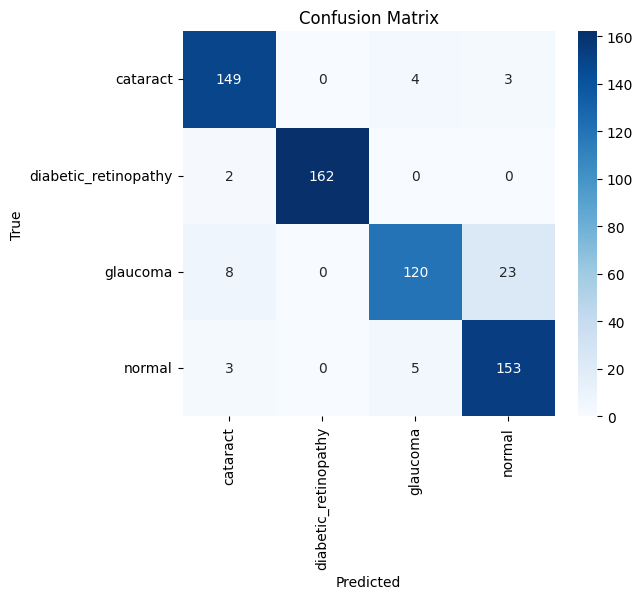


Classification Report:

                      precision    recall  f1-score   support

            cataract     0.9198    0.9551    0.9371       156
diabetic_retinopathy     1.0000    0.9878    0.9939       164
            glaucoma     0.9302    0.7947    0.8571       151
              normal     0.8547    0.9503    0.9000       161

            accuracy                         0.9241       632
           macro avg     0.9262    0.9220    0.9220       632
        weighted avg     0.9265    0.9241    0.9233       632



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report


y_pred_probs = model.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true_full = np.argmax(test_l, axis=1)


y_true = y_true_full[:len(y_pred)]

print("Prediction length:", len(y_pred))
print("True length:", len(y_true))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print("\nClassification Report:\n")
print(report)